# Macroeconomic Time-Proxy Analysis

This notebook investigates whether the three macroeconomic predictors
(unemployment rate, inflation rate, and GDP) primarily encode shared
time/cohort information rather than independent student-level variation.

We examine:

1. the number and frequency of unique macroeconomic combinations,
2. correlations among the macroeconomic variables,
3. academic outcomes across macroeconomic regimes,
4. whether removing macroeconomic variables changes predictive performance.

In [ ]:
import sys
from pathlib import Path

cwd = Path.cwd()
project_root = cwd if (cwd / "requirements.txt").exists() else cwd.parent

sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score
)

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split
)

from src.preprocessing import (
    load_data,
    TARGET_COL
)

from src.models import get_logistic_regression

# If your project already has the flexible helper we added earlier
from src.preprocessing import build_model_pipeline


sns.set_theme(style="whitegrid")

df = load_data()

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
# ============================================================
# 1. Macroeconomic Variables
# ============================================================

macro_cols = [
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

df[macro_cols].describe()

# Missing values
df[macro_cols].isna().sum()

for col in macro_cols:
    print(f"\n{col}")
    print("Number of unique values:", df[col].nunique())

    display(
        df[col]
        .value_counts()
        .sort_index()
        .to_frame("Students")
    )


Unemployment rate
Number of unique values: 10


,Students
Unemployment rate,
7.6,571
8.9,368
9.4,533
10.8,525
11.1,414
12.4,445
12.7,419
13.9,390
15.5,397



Inflation rate
Number of unique values: 9


,Students
Inflation rate,
-0.8,533
-0.3,390
0.3,362
0.5,445
0.6,414
1.4,893
2.6,571
2.8,397
3.7,419



GDP
Number of unique values: 10


,Students
GDP,
-4.06,397
-3.12,533
-1.70,419
-0.92,362
0.32,571
0.79,390
1.74,525
1.79,445
2.02,414


In [ ]:
# ============================================================
# 2. Unique Macroeconomic Combinations
# ============================================================

macro_combinations = (
    df[macro_cols]
    .drop_duplicates()
    .sort_values(macro_cols)
    .reset_index(drop=True)
)

print(
    "Number of unique macroeconomic combinations:",
    len(macro_combinations)
)

display(macro_combinations)

Number of unique macroeconomic combinations: 10


,Unemployment rate,Inflation rate,GDP
0,7.6,2.6,0.32
1,8.9,1.4,3.51
2,9.4,-0.8,-3.12
3,10.8,1.4,1.74
4,11.1,0.6,2.02
5,12.4,0.5,1.79
6,12.7,3.7,-1.70
7,13.9,-0.3,0.79
8,15.5,2.8,-4.06
9,16.2,0.3,-0.92


In [ ]:
macro_group_counts = (
    df.groupby(macro_cols)
    .size()
    .reset_index(name="Students")
    .sort_values(
        "Students",
        ascending=False
    )
    .reset_index(drop=True)
)

display(macro_group_counts)

,Unemployment rate,Inflation rate,GDP,Students
0,7.6,2.6,0.32,571
1,9.4,-0.8,-3.12,533
2,10.8,1.4,1.74,525
3,12.4,0.5,1.79,445
4,12.7,3.7,-1.70,419
5,11.1,0.6,2.02,414
6,15.5,2.8,-4.06,397
7,13.9,-0.3,0.79,390
8,8.9,1.4,3.51,368
9,16.2,0.3,-0.92,362


In [ ]:
print(
    "Students per macroeconomic combination:"
)

display(
    macro_group_counts["Students"].describe()
)

Students per macroeconomic combination:


count     10.000000
mean     442.400000
std       74.338864
min      362.000000
25%      391.750000
50%      416.500000
75%      505.000000
max      571.000000
Name: Students, dtype: float64

# 3. Visualize macroeconomic combinations

In [ ]:
# Give each unique macroeconomic combination a descriptive ID.
macro_lookup = macro_combinations.copy()

macro_lookup["Macro Regime"] = [
    f"R{i + 1}"
    for i in range(len(macro_lookup))
]

macro_lookup

,Unemployment rate,Inflation rate,GDP,Macro Regime
0,7.6,2.6,0.32,R1
1,8.9,1.4,3.51,R2
2,9.4,-0.8,-3.12,R3
3,10.8,1.4,1.74,R4
4,11.1,0.6,2.02,R5
5,12.4,0.5,1.79,R6
6,12.7,3.7,-1.70,R7
7,13.9,-0.3,0.79,R8
8,15.5,2.8,-4.06,R9
9,16.2,0.3,-0.92,R10


In [ ]:
df_macro = df.merge(
    macro_lookup,
    on=macro_cols,
    how="left"
)

df_macro[
    macro_cols + ["Macro Regime"]
].head()

regime_counts = (
    df_macro["Macro Regime"]
    .value_counts()
    .rename_axis("Macro Regime")
    .reset_index(name="Students")
)

display(regime_counts)

,Macro Regime,Students
0,R1,571
1,R3,533
2,R4,525
3,R6,445
4,R7,419
5,R5,414
6,R9,397
7,R8,390
8,R2,368
9,R10,362


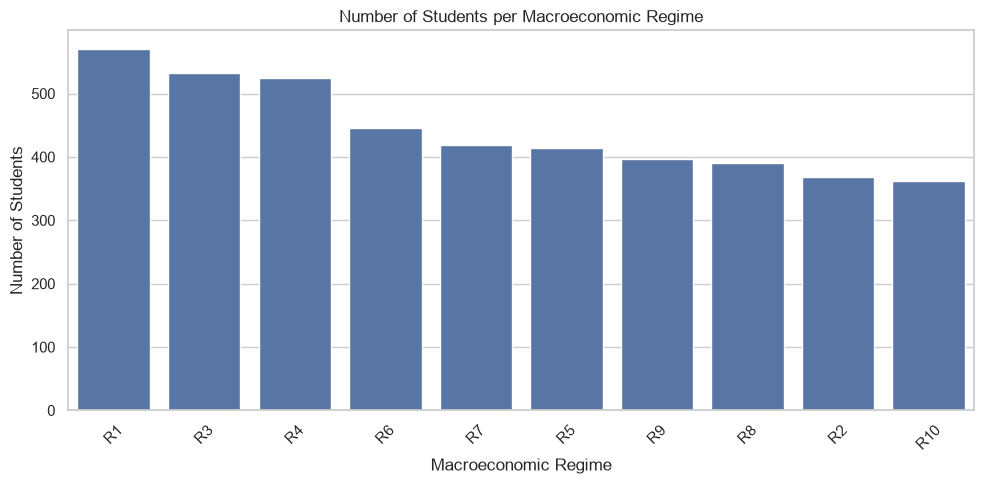

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=regime_counts,
    x="Macro Regime",
    y="Students",
    ax=ax
)

ax.set_title(
    "Number of Students per Macroeconomic Regime"
)
ax.set_xlabel("Macroeconomic Regime")
ax.set_ylabel("Number of Students")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 4. Correlation among macroeconomic variables

In [ ]:
# ============================================================
# 4. Correlation Among Macroeconomic Variables
# ============================================================

macro_corr = df[macro_cols].corr()

display(
    macro_corr.round(3)
)

,Unemployment rate,Inflation rate,GDP
Unemployment rate,1.000,-0.029,-0.335
Inflation rate,-0.029,1.000,-0.112
GDP,-0.335,-0.112,1.000


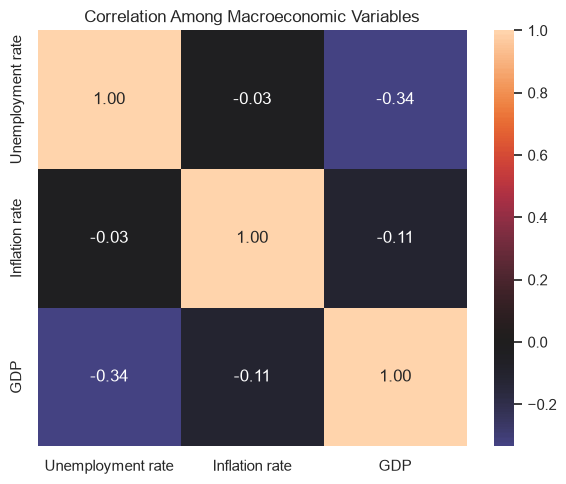

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    macro_corr,
    annot=True,
    fmt=".2f",
    center=0,
    ax=ax
)

ax.set_title(
    "Correlation Among Macroeconomic Variables"
)

plt.tight_layout()
plt.show()

# 6. Plot the macro regimes themselves

In [ ]:
macro_regime_long = (
    macro_lookup
    .melt(
        id_vars="Macro Regime",
        value_vars=macro_cols,
        var_name="Variable",
        value_name="Value"
    )
)

macro_regime_scaled = macro_lookup.copy()

for col in macro_cols:
    macro_regime_scaled[col] = (
        macro_regime_scaled[col]
        - macro_regime_scaled[col].mean()
    ) / macro_regime_scaled[col].std()



In [ ]:
macro_scaled_long = (
    macro_regime_scaled
    .melt(
        id_vars="Macro Regime",
        value_vars=macro_cols,
        var_name="Variable",
        value_name="Standardized Value"
    )
)

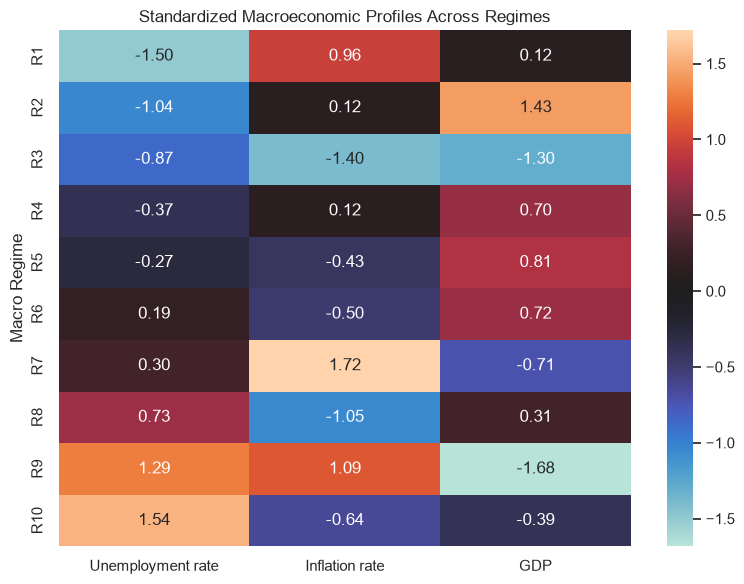

In [ ]:
regime_heatmap = (
    macro_regime_scaled
    .set_index("Macro Regime")[macro_cols]
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    regime_heatmap,
    annot=True,
    fmt=".2f",
    center=0,
    ax=ax
)

ax.set_title(
    "Standardized Macroeconomic Profiles Across Regimes"
)

plt.tight_layout()
plt.show()

# 6. Compare outcome distributions across macro regimes

In [ ]:
# ============================================================
# 7. Academic Outcome by Macroeconomic Regime
# ============================================================

regime_outcomes = pd.crosstab(
    df_macro["Macro Regime"],
    df_macro[TARGET_COL],
    normalize="index"
)

display(
    regime_outcomes.round(3)
)

Target,Dropout,Enrolled,Graduate
Macro Regime,,,
R1,0.354,0.208,0.438
R10,0.384,0.127,0.489
R2,0.277,0.209,0.514
R3,0.326,0.205,0.469
R4,0.347,0.171,0.482
R5,0.283,0.162,0.556
R6,0.240,0.202,0.557
R7,0.337,0.150,0.513
R8,0.303,0.164,0.533


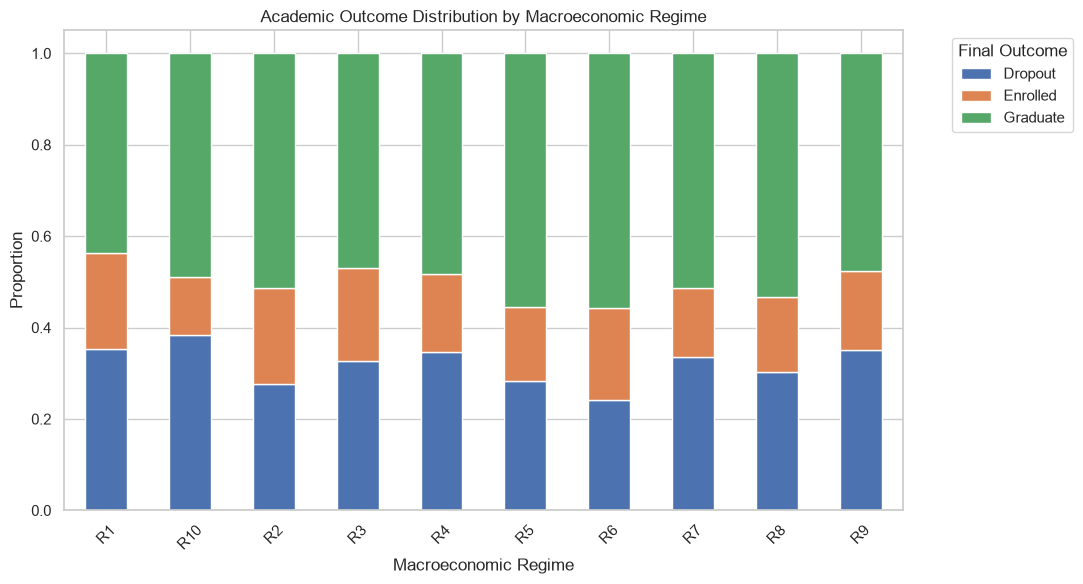

In [ ]:
ax = regime_outcomes.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

ax.set_title(
    "Academic Outcome Distribution by Macroeconomic Regime"
)

ax.set_xlabel("Macroeconomic Regime")
ax.set_ylabel("Proportion")

plt.legend(
    title="Final Outcome",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 7. Quantify outcome rates by regime

In [ ]:
regime_summary = (
    regime_outcomes
    .reset_index()
)

regime_summary["Students"] = (
    regime_summary["Macro Regime"]
    .map(
        df_macro["Macro Regime"]
        .value_counts()
    )
)

display(
    regime_summary.round(3)
)

Target,Macro Regime,Dropout,Enrolled,Graduate,Students
0,R1,0.354,0.208,0.438,571
1,R10,0.384,0.127,0.489,362
2,R2,0.277,0.209,0.514,368
3,R3,0.326,0.205,0.469,533
4,R4,0.347,0.171,0.482,525
5,R5,0.283,0.162,0.556,414
6,R6,0.240,0.202,0.557,445
7,R7,0.337,0.150,0.513,419
8,R8,0.303,0.164,0.533,390
9,R9,0.350,0.174,0.476,397


In [ ]:
if "Dropout" in regime_summary.columns:
    display(
        regime_summary
        .sort_values(
            "Dropout",
            ascending=False
        )
        .round(3)
    )

Target,Macro Regime,Dropout,Enrolled,Graduate,Students
1,R10,0.384,0.127,0.489,362
0,R1,0.354,0.208,0.438,571
9,R9,0.350,0.174,0.476,397
4,R4,0.347,0.171,0.482,525
7,R7,0.337,0.150,0.513,419
3,R3,0.326,0.205,0.469,533
8,R8,0.303,0.164,0.533,390
5,R5,0.283,0.162,0.556,414
2,R2,0.277,0.209,0.514,368
6,R6,0.240,0.202,0.557,445


# 8. Test whether a single regime variable summarizes the macro variables

In [ ]:
df_macro["Macro Regime Code"] = (
    pd.Categorical(
        df_macro["Macro Regime"]
    ).codes
)

print(
    "Original macroeconomic predictors:",
    len(macro_cols)
)

print(
    "Unique macroeconomic regimes:",
    df_macro["Macro Regime"].nunique()
)

Original macroeconomic predictors: 3
Unique macroeconomic regimes: 10


# 9. Main modeling experiment: with vs without macro variables

In [ ]:
# ============================================================
# 9. Logistic Regression With vs Without Macroeconomic Features
# ============================================================

X = df.drop(
    columns=[TARGET_COL]
)

y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

full_feature_cols = list(
    X.columns
)

no_macro_feature_cols = [
    col for col in X.columns
    if col not in macro_cols
]

print(
    "Full model predictors:",
    len(full_feature_cols)
)

print(
    "Without macro predictors:",
    len(no_macro_feature_cols)
)

Full model predictors: 34
Without macro predictors: 31


In [ ]:
# Fit full model
full_macro_pipe = build_model_pipeline(
    model=get_logistic_regression(
        random_state=42
    ),
    feature_cols=full_feature_cols,
    scale_numeric=True
)

full_macro_pipe.fit(
    X_train[full_feature_cols],
    y_train
)

pred_with_macro = full_macro_pipe.predict(
    X_test[full_feature_cols]
)

# Fit without macro
no_macro_pipe = build_model_pipeline(
    model=get_logistic_regression(
        random_state=42
    ),
    feature_cols=no_macro_feature_cols,
    scale_numeric=True
)

no_macro_pipe.fit(
    X_train[no_macro_feature_cols],
    y_train
)

pred_without_macro = no_macro_pipe.predict(
    X_test[no_macro_feature_cols]
)

In [ ]:
def evaluate_model(
    y_true,
    y_pred,
    model_name
):
    """
    Return overall and class-specific performance metrics.
    """

    return {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro"
        ),

        "Dropout Recall": recall_score(
            y_true,
            y_pred,
            labels=["Dropout"],
            average=None
        )[0],

        "Enrolled Recall": recall_score(
            y_true,
            y_pred,
            labels=["Enrolled"],
            average=None
        )[0],

        "Graduate Recall": recall_score(
            y_true,
            y_pred,
            labels=["Graduate"],
            average=None
        )[0]
    }

In [ ]:
with_macro_results = evaluate_model(
    y_test,
    pred_with_macro,
    "With Macroeconomic Features"
)

without_macro_results = evaluate_model(
    y_test,
    pred_without_macro,
    "Without Macroeconomic Features"
)

macro_model_results = pd.DataFrame([
    with_macro_results,
    without_macro_results
])

display(
    macro_model_results.round(3)
)

,Model,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall
0,With Macroeconomic Features,0.723,0.685,0.69,0.616,0.783
1,Without Macroeconomic Features,0.728,0.689,0.69,0.623,0.790


In [ ]:
baseline_macro_f1 = macro_model_results.loc[
    macro_model_results["Model"]
    == "With Macroeconomic Features",
    "Macro F1"
].iloc[0]

macro_model_results["Delta Macro F1 vs Full"] = (
    macro_model_results["Macro F1"]
    - baseline_macro_f1
)

display(
    macro_model_results.round(4)
)

,Model,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall,Delta Macro F1 vs Full
0,With Macroeconomic Features,0.7232,0.6852,0.6901,0.6164,0.7828,0.0000
1,Without Macroeconomic Features,0.7277,0.6894,0.6901,0.6226,0.7896,0.0041


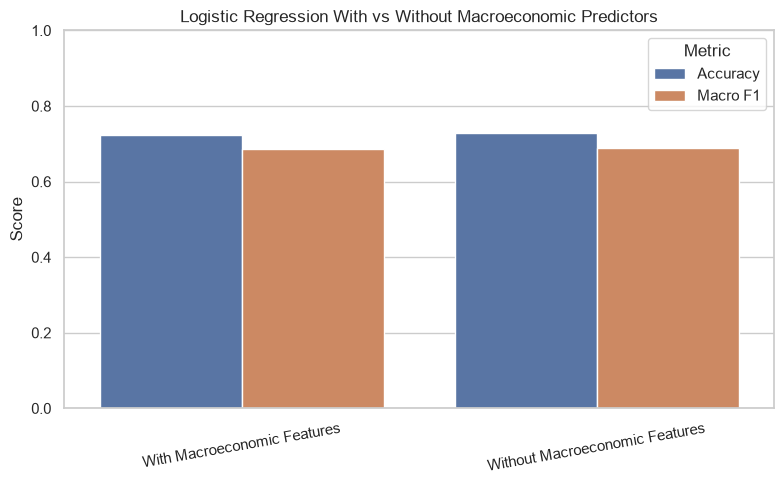

In [ ]:
performance_long = (
    macro_model_results
    .melt(
        id_vars="Model",
        value_vars=[
            "Accuracy",
            "Macro F1"
        ],
        var_name="Metric",
        value_name="Score"
    )
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=performance_long,
    x="Model",
    y="Score",
    hue="Metric",
    ax=ax
)

ax.set_ylim(0, 1)

ax.set_title(
    "Logistic Regression With vs Without Macroeconomic Predictors"
)

ax.set_xlabel("")
ax.set_ylabel("Score")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

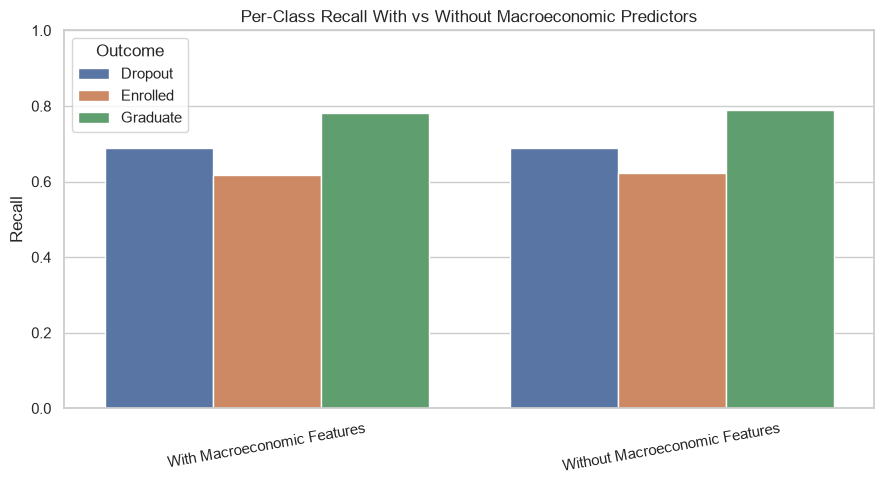

In [ ]:
recall_long = (
    macro_model_results
    .melt(
        id_vars="Model",
        value_vars=[
            "Dropout Recall",
            "Enrolled Recall",
            "Graduate Recall"
        ],
        var_name="Outcome",
        value_name="Recall"
    )
)

recall_long["Outcome"] = (
    recall_long["Outcome"]
    .str.replace(
        " Recall",
        "",
        regex=False
    )
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=recall_long,
    x="Model",
    y="Recall",
    hue="Outcome",
    ax=ax
)

ax.set_ylim(0, 1)

ax.set_title(
    "Per-Class Recall With vs Without Macroeconomic Predictors"
)

ax.set_xlabel("")
ax.set_ylabel("Recall")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

# CV

In [ ]:
# ============================================================
# 14. 5-Fold Cross-Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "macro_recall": "recall_macro"
}

In [ ]:
full_cv_pipe = build_model_pipeline(
    model=get_logistic_regression(
        random_state=42
    ),
    feature_cols=full_feature_cols,
    scale_numeric=True
)

full_cv = cross_validate(
    full_cv_pipe,
    X_train[full_feature_cols],
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

no_macro_cv_pipe = build_model_pipeline(
    model=get_logistic_regression(
        random_state=42
    ),
    feature_cols=no_macro_feature_cols,
    scale_numeric=True
)

no_macro_cv = cross_validate(
    no_macro_cv_pipe,
    X_train[no_macro_feature_cols],
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

macro_cv_results = pd.DataFrame({
    "Model": [
        "With Macroeconomic Features",
        "Without Macroeconomic Features"
    ],

    "Mean Accuracy": [
        full_cv["test_accuracy"].mean(),
        no_macro_cv["test_accuracy"].mean()
    ],

    "SD Accuracy": [
        full_cv["test_accuracy"].std(),
        no_macro_cv["test_accuracy"].std()
    ],

    "Mean Macro F1": [
        full_cv["test_macro_f1"].mean(),
        no_macro_cv["test_macro_f1"].mean()
    ],

    "SD Macro F1": [
        full_cv["test_macro_f1"].std(),
        no_macro_cv["test_macro_f1"].std()
    ],

    "Mean Macro Recall": [
        full_cv["test_macro_recall"].mean(),
        no_macro_cv["test_macro_recall"].mean()
    ],

    "SD Macro Recall": [
        full_cv["test_macro_recall"].std(),
        no_macro_cv["test_macro_recall"].std()
    ]
})

display(
    macro_cv_results.round(4)
)

,Model,Mean Accuracy,SD Accuracy,Mean Macro F1,SD Macro F1,Mean Macro Recall,SD Macro Recall
0,With Macroeconomic Features,0.7570,0.0151,0.7157,0.0169,0.7229,0.0179
1,Without Macroeconomic Features,0.7547,0.0143,0.7122,0.0131,0.7188,0.0126


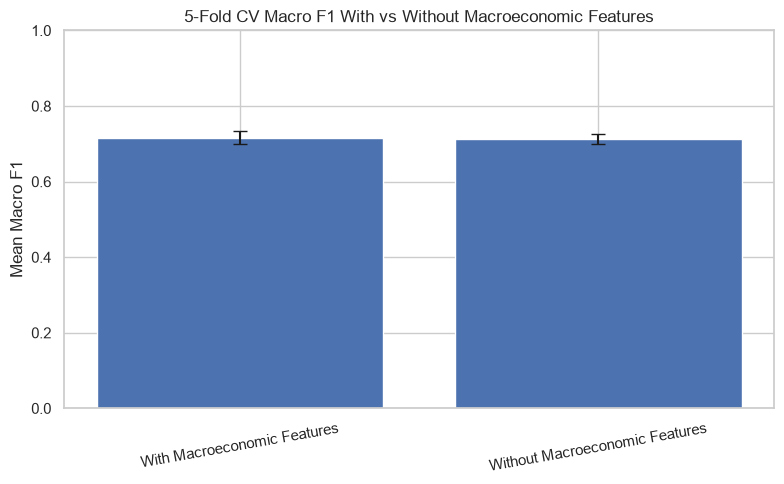

In [ ]:
# ============================================================
# Cross-Validation Performance Comparison
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    macro_cv_results["Model"],
    macro_cv_results["Mean Macro F1"],
    yerr=macro_cv_results["SD Macro F1"],
    capsize=5
)

ax.set_ylim(0, 1)
ax.set_title(
    "5-Fold CV Macro F1 With vs Without Macroeconomic Features"
)
ax.set_ylabel("Mean Macro F1")
ax.set_xlabel("")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Final Holdout + Cross-Validation Summary
# ============================================================

summary_table = pd.DataFrame({
    "Model": [
        "With Macroeconomic Features",
        "Without Macroeconomic Features"
    ],

    "Holdout Accuracy": [
        macro_model_results.loc[
            macro_model_results["Model"]
            == "With Macroeconomic Features",
            "Accuracy"
        ].iloc[0],

        macro_model_results.loc[
            macro_model_results["Model"]
            == "Without Macroeconomic Features",
            "Accuracy"
        ].iloc[0]
    ],

    "Holdout Macro F1": [
        macro_model_results.loc[
            macro_model_results["Model"]
            == "With Macroeconomic Features",
            "Macro F1"
        ].iloc[0],

        macro_model_results.loc[
            macro_model_results["Model"]
            == "Without Macroeconomic Features",
            "Macro F1"
        ].iloc[0]
    ],

    "CV Mean Macro F1": [
        macro_cv_results.loc[
            macro_cv_results["Model"]
            == "With Macroeconomic Features",
            "Mean Macro F1"
        ].iloc[0],

        macro_cv_results.loc[
            macro_cv_results["Model"]
            == "Without Macroeconomic Features",
            "Mean Macro F1"
        ].iloc[0]
    ],

    "CV SD Macro F1": [
        macro_cv_results.loc[
            macro_cv_results["Model"]
            == "With Macroeconomic Features",
            "SD Macro F1"
        ].iloc[0],

        macro_cv_results.loc[
            macro_cv_results["Model"]
            == "Without Macroeconomic Features",
            "SD Macro F1"
        ].iloc[0]
    ]
})

display(summary_table.round(4))

,Model,Holdout Accuracy,Holdout Macro F1,CV Mean Macro F1,CV SD Macro F1
0,With Macroeconomic Features,0.7232,0.6852,0.7157,0.0169
1,Without Macroeconomic Features,0.7277,0.6894,0.7122,0.0131


# Regime instead of three macro variables

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from src.preprocessing import (
    NUMERIC_COLS,
    CATEGORICAL_COLS,
    BINARY_COLS
)

In [ ]:
# Remove the original three numeric macro variables.
regime_numeric_cols = [
    col for col in NUMERIC_COLS
    if col not in macro_cols
]

# Add Macro Regime to the existing categorical predictors.
regime_categorical_cols = (
    CATEGORICAL_COLS
    + ["Macro Regime"]
)

regime_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            regime_numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            regime_categorical_cols
        ),
        (
            "bin",
            "passthrough",
            BINARY_COLS
        )
    ]
)

X_regime = df_macro.drop(
    columns=[
        TARGET_COL,
        "Macro Regime Code"
    ]
)

y_regime = df_macro[TARGET_COL]

# Reuse the exact same row indices as the original split.
X_train_regime = X_regime.loc[X_train.index]
X_test_regime = X_regime.loc[X_test.index]

In [ ]:
regime_pipe = Pipeline([
    (
        "preprocess",
        regime_preprocessor
    ),
    (
        "model",
        get_logistic_regression(
            random_state=42
        )
    )
])

regime_pipe.fit(
    X_train_regime,
    y_train
)

pred_regime = regime_pipe.predict(
    X_test_regime
)

regime_results = evaluate_model(
    y_test,
    pred_regime,
    "Macro Regime Instead of 3 Variables"
)

regime_results

{'Model': 'Macro Regime Instead of 3 Variables',
 'Accuracy': 0.7197740112994351,
 'Macro F1': 0.6823958441383092,
 'Dropout Recall': np.float64(0.6936619718309859),
 'Enrolled Recall': np.float64(0.6163522012578616),
 'Graduate Recall': np.float64(0.7737556561085973)}

In [ ]:
macro_representation_results = pd.DataFrame([
    with_macro_results,
    without_macro_results,
    regime_results
])

display(
    macro_representation_results.round(4)
)

,Model,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall
0,With Macroeconomic Features,0.7232,0.6852,0.6901,0.6164,0.7828
1,Without Macroeconomic Features,0.7277,0.6894,0.6901,0.6226,0.7896
2,Macro Regime Instead of 3 Variables,0.7198,0.6824,0.6937,0.6164,0.7738


## Conclusion

The 4,424 students fall into only 10 unique combinations of unemployment, inflation, and GDP values, with roughly 360–570 students sharing each combination. This strongly suggests that the macroeconomic variables describe shared cohort or time-period conditions rather than student-specific variation.

Academic outcomes vary across these regimes; for example, dropout proportions range from approximately 24% to 38%. However, the predictive contribution of the macroeconomic variables is small. On the holdout set, removing them slightly increased macro F1 from 0.685 to 0.689. In 5-fold cross-validation on the training data, retaining them produced a slightly higher mean macro F1 (0.716 vs. 0.712). These differences are small relative to fold-to-fold variation.

Therefore, the macroeconomic variables appear to encode meaningful shared economic regimes, but they provide limited incremental predictive information once the remaining student-level predictors are included. Because the dataset does not contain a verified calendar-year variable, these groups should be interpreted as macroeconomic regimes rather than confirmed yearly cohorts.